In [52]:
# 데이터 로드
from datasets import load_dataset
import pandas as pd

dataset=load_dataset("epinfomax/mbti-korean-binary-dataset")

train_df=pd.DataFrame(dataset["train"])
valid_df=pd.DataFrame(dataset["validation"])
test_df=pd.DataFrame(dataset["test"])

print(dataset)
print(train_df.head())
print(train_df.columns)

DatasetDict({
    train: Dataset({
        features: ['text', 'label_ei', 'label_sn', 'label_tf', 'label_jp'],
        num_rows: 18619
    })
    validation: Dataset({
        features: ['text', 'label_ei', 'label_sn', 'label_tf', 'label_jp'],
        num_rows: 2327
    })
    test: Dataset({
        features: ['text', 'label_ei', 'label_sn', 'label_tf', 'label_jp'],
        num_rows: 2328
    })
})
                                                text  label_ei  label_sn  \
0  역시 인생은 혼자야 혼자가 편해 나 혼자 뭐 뭐 뭐 해야지 하면서 나를 더 챙겨주려...         1         1   
1      어렵게 생각하지 마세요~~  아마 infp님이 어렵게 생각을 해서 어려운 거예요~         0         0   
2  제 남자친구 estj인데 저희는 만약 합정에서 데이트하고 싶다 하면 그날 합정의 점...         1         1   
3                         infj intj 두 유형 중 하나일 거 같아요         1         1   
4        자신의 감정이 앞서서 이성 감정을 제대로 파악 못하고 너무 들이대는 거 같아요         0         1   

   label_tf  label_jp  
0         1         1  
1         0         0  
2         1         1  
3         1         0  
4         0         

In [53]:
# 데이터 확인

dfs = {
    'train':train_df,
    'validation':valid_df,
    'test':test_df
}
TARGET_COLS = ['label_ei', 'label_sn', 'label_tf', 'label_jp']

for split_name, df in dfs.items():
    print(f'[{split_name}]')
    print('shape:',df.shape)
    print('columns:',df.columns.to_list())

    print('\n결측치 개수')
    print(df[['text']+TARGET_COLS].isna().sum())

    print('\n완전 중복 행 개수')
    print(df.duplicated().sum())

    print('\ntext 중복 개수')
    print(df['text'].duplicated().sum())

[train]
shape: (18619, 5)
columns: ['text', 'label_ei', 'label_sn', 'label_tf', 'label_jp']

결측치 개수
text        0
label_ei    0
label_sn    0
label_tf    0
label_jp    0
dtype: int64

완전 중복 행 개수
45

text 중복 개수
45
[validation]
shape: (2327, 5)
columns: ['text', 'label_ei', 'label_sn', 'label_tf', 'label_jp']

결측치 개수
text        0
label_ei    0
label_sn    0
label_tf    0
label_jp    0
dtype: int64

완전 중복 행 개수
2

text 중복 개수
2
[test]
shape: (2328, 5)
columns: ['text', 'label_ei', 'label_sn', 'label_tf', 'label_jp']

결측치 개수
text        0
label_ei    0
label_sn    0
label_tf    0
label_jp    0
dtype: int64

완전 중복 행 개수
0

text 중복 개수
0


In [54]:
# 라벨 값 확인
for split_name, df in dfs.items():
    print(f'[{split_name}] 라벨 고유 값')

    for col in TARGET_COLS:
        print(col, sorted(df[col].dropna().unique()))

[train] 라벨 고유 값
label_ei [0, 1]
label_sn [0, 1]
label_tf [0, 1]
label_jp [0, 1]
[validation] 라벨 고유 값
label_ei [0, 1]
label_sn [0, 1]
label_tf [0, 1]
label_jp [0, 1]
[test] 라벨 고유 값
label_ei [0, 1]
label_sn [0, 1]
label_tf [0, 1]
label_jp [0, 1]


In [55]:
# MBTI 언급 제거
import re

mbti_pattern = r"\b(enfj|enfp|entj|entp|esfj|esfp|estj|estp|infj|infp|intj|intp|isfj|isfp|istj|istp)\b"

def remove_mbti_words(text):
	text=str(text).lower()
	text=re.sub(mbti_pattern," ",text)
	text=re.sub(r"\s+"," ",text).strip()
	return text

for split_name, df in dfs.items():
    df['text_no_mbti'] = [remove_mbti_words(text) for text in df['text']]
    
    print(split_name)
    print(df[['text', 'text_no_mbti']].head(3))

train
                                                text  \
0  역시 인생은 혼자야 혼자가 편해 나 혼자 뭐 뭐 뭐 해야지 하면서 나를 더 챙겨주려...   
1      어렵게 생각하지 마세요~~  아마 infp님이 어렵게 생각을 해서 어려운 거예요~   
2  제 남자친구 estj인데 저희는 만약 합정에서 데이트하고 싶다 하면 그날 합정의 점...   

                                        text_no_mbti  
0  역시 인생은 혼자야 혼자가 편해 나 혼자 뭐 뭐 뭐 해야지 하면서 나를 더 챙겨주려...  
1       어렵게 생각하지 마세요~~ 아마 infp님이 어렵게 생각을 해서 어려운 거예요~  
2  제 남자친구 estj인데 저희는 만약 합정에서 데이트하고 싶다 하면 그날 합정의 점...  
validation
                                                text  \
0  저도 그래요..  근데 조금 입장 바꿔놓고 생각해 보니까 정말 깊은 친구 한두 명한...   
1  1.3. 매일 일상처럼 연락하면 좋습니다. 2. 이 팁은 원래 눈 잘못 마주치는 편...   
2            정말 호감입니다...!! 바빠도 연락하고 사소한 챙김은 사랑이거든요..   

                                        text_no_mbti  
0  저도 그래요.. 근데 조금 입장 바꿔놓고 생각해 보니까 정말 깊은 친구 한두 명한테...  
1  1.3. 매일 일상처럼 연락하면 좋습니다. 2. 이 팁은 원래 눈 잘못 마주치는 편...  
2            정말 호감입니다...!! 바빠도 연락하고 사소한 챙김은 사랑이거든요..  
test
                                  text                        text_no_mbti
0   생각이 많을 때 

In [56]:
# 기본 전처리 먼저 적용, 성능 확인
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def base_preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\s+','',text) # url제거
    text = re.sub(r'\s+','',text).strip() # 공백 정리
    return text

train_df['text_base'] = [base_preprocess(text) for text in train_df['text']]
valid_df['text_base'] = [base_preprocess(text) for text in valid_df['text']]
test_df['text_base'] = [base_preprocess(text) for text in test_df['text']]

model=LinearSVC(
C=1.0,
max_iter=5000,
random_state=42
)

results = []

for target in TARGET_COLS:
    print('target:', target)

    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9
    )

    X_train = tfidf.fit_transform(train_df['text_base'])
    X_valid = tfidf.transform(valid_df['text_base'])
    y_train = train_df[target]
    y_valid = valid_df[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    macro_f1 = f1_score(y_valid, y_pred, average='macro')
    weighted_f1 = f1_score(y_valid, y_pred, average='weighted')
    cm = confusion_matrix(y_valid, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Confusion Matrix:")
    print(cm)

    results.append({
        "label": target,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

target: label_ei
Accuracy: 0.6394
Macro F1: 0.3945
Weighted F1: 0.5046
Confusion Matrix:
[[   4  827]
 [  12 1484]]
target: label_sn
Accuracy: 0.6562
Macro F1: 0.4009
Weighted F1: 0.5231
Confusion Matrix:
[[   4  796]
 [   4 1523]]
target: label_tf
Accuracy: 0.5161
Macro F1: 0.3587
Weighted F1: 0.3689
Confusion Matrix:
[[  24 1102]
 [  24 1177]]
target: label_jp
Accuracy: 0.6218
Macro F1: 0.399
Weighted F1: 0.4891
Confusion Matrix:
[[  15  862]
 [  18 1432]]


In [57]:
# 결과표와 최종 점수
result_df = pd.DataFrame(results)
final_score = result_df['macro_f1'].mean()

print(result_df)
print('final score:', round(final_score, 4))

      label  accuracy  macro_f1  weighted_f1
0  label_ei  0.639450  0.394531     0.504579
1  label_sn  0.656210  0.400946     0.523116
2  label_tf  0.516115  0.358661     0.368903
3  label_jp  0.621831  0.398962     0.489085
final score: 0.3883


In [58]:
# mbti 제거 버전 결과 확인

train_df['text_base_'] = [base_preprocess(text) for text in train_df['text_no_mbti']]
valid_df['text_base_'] = [base_preprocess(text) for text in valid_df['text_no_mbti']]

results_remove = []
for target in TARGET_COLS:
    print('target:', target)

    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9
    )

    X_train = tfidf.fit_transform(train_df['text_base_'])
    X_valid = tfidf.transform(valid_df['text_base_'])
    y_train = train_df[target]
    y_valid = valid_df[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    macro_f1 = f1_score(y_valid, y_pred, average='macro')
    weighted_f1 = f1_score(y_valid, y_pred, average='weighted')
    cm = confusion_matrix(y_valid, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Confusion Matrix:")
    print(cm)

    results_remove.append({
        "label": target,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

result_remove_df = pd.DataFrame(results_remove)
remove_final_score = result_remove_df['macro_f1'].mean()

print(results_remove)
print('final score:', round(remove_final_score, 4))

# 결과에서 별 차이가 없음 -> mbti 제거하지 않은 버전 사용

target: label_ei
Accuracy: 0.6394
Macro F1: 0.3945
Weighted F1: 0.5046
Confusion Matrix:
[[   4  827]
 [  12 1484]]
target: label_sn
Accuracy: 0.6571
Macro F1: 0.4024
Weighted F1: 0.5243
Confusion Matrix:
[[   5  795]
 [   3 1524]]
target: label_tf
Accuracy: 0.5157
Macro F1: 0.357
Weighted F1: 0.3673
Confusion Matrix:
[[  22 1104]
 [  23 1178]]
target: label_jp
Accuracy: 0.6218
Macro F1: 0.397
Weighted F1: 0.4876
Confusion Matrix:
[[  13  864]
 [  16 1434]]
[{'label': 'label_ei', 'accuracy': 0.6394499355393211, 'macro_f1': 0.39453079814137193, 'weighted_f1': 0.5045789240668017}, {'label': 'label_sn', 'accuracy': 0.6570691877954448, 'macro_f1': 0.4024439690458906, 'weighted_f1': 0.5243087050767833}, {'label': 'label_tf', 'accuracy': 0.5156854318865493, 'macro_f1': 0.3570015444051417, 'weighted_f1': 0.3672967793195929}, {'label': 'label_jp', 'accuracy': 0.6218306832831972, 'macro_f1': 0.3969528413682294, 'weighted_f1': 0.48763194299896595}]
final score: 0.3877


In [59]:
# Char n-gram 사용
results_char_wb = []

for target in TARGET_COLS:

    tfidf = TfidfVectorizer(
        max_features=20000,
        ngram_range=(2,5),
        min_df=2,
        max_df=0.9,
        analyzer='char_wb'
    )

    X_train = tfidf.fit_transform(train_df['text_base'])
    X_valid = tfidf.transform(valid_df['text_base'])
    y_train = train_df[target]
    y_valid = valid_df[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    macro_f1 = f1_score(y_valid, y_pred, average='macro')
    weighted_f1 = f1_score(y_valid, y_pred, average='weighted')
    cm = confusion_matrix(y_valid, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Confusion Matrix:")
    print(cm)

    results_char_wb.append({
        'experiment':'char_wb_2_5',
        'label': target,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix':cm
    })

result_char_wb_df = pd.DataFrame(results_char_wb)
char_wb_final_score = result_char_wb_df['macro_f1'].mean()
    

Accuracy: 0.5956
Macro F1: 0.5392
Weighted F1: 0.5853
Confusion Matrix:
[[ 286  545]
 [ 396 1100]]
Accuracy: 0.6274
Macro F1: 0.5502
Weighted F1: 0.6084
Confusion Matrix:
[[ 248  552]
 [ 315 1212]]
Accuracy: 0.5883
Macro F1: 0.5882
Weighted F1: 0.5884
Confusion Matrix:
[[664 462]
 [496 705]]
Accuracy: 0.581
Macro F1: 0.5483
Weighted F1: 0.5782
Confusion Matrix:
[[363 514]
 [461 989]]


In [60]:
# base와 비교
compare_df = pd.concat(
    [result_df.assign(experiment='word_1_2'), result_char_wb_df], ignore_index=True
)
print(compare_df[['experiment', 'label', 'accuracy', 'macro_f1', 'weighted_f1']])

    experiment     label  accuracy  macro_f1  weighted_f1
0     word_1_2  label_ei  0.639450  0.394531     0.504579
1     word_1_2  label_sn  0.656210  0.400946     0.523116
2     word_1_2  label_tf  0.516115  0.358661     0.368903
3     word_1_2  label_jp  0.621831  0.398962     0.489085
4  char_wb_2_5  label_ei  0.595617  0.539235     0.585296
5  char_wb_2_5  label_sn  0.627417  0.550229     0.608440
6  char_wb_2_5  label_tf  0.588311  0.588183     0.588417
7  char_wb_2_5  label_jp  0.581006  0.548318     0.578238


In [61]:
# Char n-gram 실험 -> analyzer='char'로 변경
results_char = []

for target in TARGET_COLS:

    tfidf = TfidfVectorizer(
        max_features=20000,
        ngram_range=(2,5),
        min_df=2,
        max_df=0.9,
        analyzer='char'
    )

    X_train = tfidf.fit_transform(train_df['text_base'])
    X_valid = tfidf.transform(valid_df['text_base'])
    y_train = train_df[target]
    y_valid = valid_df[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    macro_f1 = f1_score(y_valid, y_pred, average='macro')
    weighted_f1 = f1_score(y_valid, y_pred, average='weighted')
    cm = confusion_matrix(y_valid, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Confusion Matrix:")
    print(cm)

    results_char.append({
        'experiment':'char_2_5',
        'label': target,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix':cm
    })

result_char_df = pd.DataFrame(results_char)
char_final_score = result_char_df['macro_f1'].mean()

Accuracy: 0.5956
Macro F1: 0.5396
Weighted F1: 0.5855
Confusion Matrix:
[[ 287  544]
 [ 397 1099]]
Accuracy: 0.624
Macro F1: 0.5465
Weighted F1: 0.605
Confusion Matrix:
[[ 245  555]
 [ 320 1207]]
Accuracy: 0.587
Macro F1: 0.5868
Weighted F1: 0.5871
Confusion Matrix:
[[655 471]
 [490 711]]
Accuracy: 0.5716
Macro F1: 0.5402
Weighted F1: 0.5697
Confusion Matrix:
[[361 516]
 [481 969]]


In [62]:
# 실험결과 비교
compare_df = pd.concat(
    [result_char_wb_df, result_char_df], ignore_index=True
)
print(compare_df[['experiment', 'label', 'accuracy', 'macro_f1', 'weighted_f1']])

# 큰 차이는 없지만 미세하게 char_wb_2_5가 더 성능이 좋음

    experiment     label  accuracy  macro_f1  weighted_f1
0  char_wb_2_5  label_ei  0.595617  0.539235     0.585296
1  char_wb_2_5  label_sn  0.627417  0.550229     0.608440
2  char_wb_2_5  label_tf  0.588311  0.588183     0.588417
3  char_wb_2_5  label_jp  0.581006  0.548318     0.578238
4     char_2_5  label_ei  0.595617  0.539550     0.585467
5     char_2_5  label_sn  0.623979  0.546468     0.605045
6     char_2_5  label_tf  0.587022  0.586783     0.587103
7     char_2_5  label_jp  0.571551  0.540159     0.569744


In [63]:
# 형태소 기반 분석 실험 (Okt)

from konlpy.tag import Okt

okt = Okt()

def okt_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()

    pos_list = okt.pos(text, norm=True, stem=True)
    keep_pos = {'Noun', 'Verb', 'Adjective', 'Adverb'} # 명사 동사 형용사 부사

    tokens = [word for word, pos in pos_list if pos in keep_pos and len(word) >= 2]

    return ''.join(tokens)

train_df['text_okt'] = [okt_tokenize(text) for text in train_df['text']]
valid_df['text_okt'] = [okt_tokenize(text) for text in valid_df['text']]

for i in range(3):
    print("원본:", train_df.loc[i, 'text'])
    print("형태소:", train_df.loc[i, 'text_okt'])

원본: 역시 인생은 혼자야 혼자가 편해 나 혼자 뭐 뭐 뭐 해야지 하면서 나를 더 챙겨주려고 해요  아니면 이것저것 하려고 하던가
형태소: 역시인생혼자혼자편하다혼자하다하다나르다챙기다아니다하다하다
원본: 어렵게 생각하지 마세요~~  아마 infp님이 어렵게 생각을 해서 어려운 거예요~
형태소: 어렵다생각하다말다아마어렵다생각하다어렵다
원본: 제 남자친구 estj인데 저희는 만약 합정에서 데이트하고 싶다 하면 그날 합정의 점심 카페 저녁까지 어디 갈지 제가 가고 싶은 곳 정해서 리스트 다 보내요.  그리고 서로 전화하면서 확정 짓습니다 ㅎ
형태소: 남자친구저희만약합정데이트싶다하다그날정의점심카페저녁어디갈다가다싶다정해리스트보내다서로전화하다확정짓다


In [64]:
results_okt = []

for target in TARGET_COLS:

    tfidf = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        token_pattern=r'(?u)\b\w+\b'
    )

    X_train = tfidf.fit_transform(train_df['text_okt'])
    X_valid = tfidf.transform(valid_df['text_okt'])
    y_train = train_df[target]
    y_valid = valid_df[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    macro_f1 = f1_score(y_valid, y_pred, average='macro')
    weighted_f1 = f1_score(y_valid, y_pred, average='weighted')
    cm = confusion_matrix(y_valid, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Confusion Matrix:")
    print(cm)

    results_okt.append({
        'experiment':'okt_pos_nva_adv',
        'label': target,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix':cm
    })

result_okt_df = pd.DataFrame(results_okt)
okt_final_score = result_okt_df['macro_f1'].mean()

Accuracy: 0.6429
Macro F1: 0.3913
Weighted F1: 0.5031
Confusion Matrix:
[[   0  831]
 [   0 1496]]
Accuracy: 0.6562
Macro F1: 0.3962
Weighted F1: 0.52
Confusion Matrix:
[[   0  800]
 [   0 1527]]
Accuracy: 0.5161
Macro F1: 0.3404
Weighted F1: 0.3514
Confusion Matrix:
[[   0 1126]
 [   0 1201]]
Accuracy: 0.6231
Macro F1: 0.3839
Weighted F1: 0.4784
Confusion Matrix:
[[   0  877]
 [   0 1450]]


In [65]:
# base,char과 비교
compare_df = pd.concat(
    [result_df.assign(experiment='word_1_2'), result_char_wb_df, result_okt_df], ignore_index=True
)
print(compare_df[['experiment', 'label', 'accuracy', 'macro_f1', 'weighted_f1']])

         experiment     label  accuracy  macro_f1  weighted_f1
0          word_1_2  label_ei  0.639450  0.394531     0.504579
1          word_1_2  label_sn  0.656210  0.400946     0.523116
2          word_1_2  label_tf  0.516115  0.358661     0.368903
3          word_1_2  label_jp  0.621831  0.398962     0.489085
4       char_wb_2_5  label_ei  0.595617  0.539235     0.585296
5       char_wb_2_5  label_sn  0.627417  0.550229     0.608440
6       char_wb_2_5  label_tf  0.588311  0.588183     0.588417
7       char_wb_2_5  label_jp  0.581006  0.548318     0.578238
8   okt_pos_nva_adv  label_ei  0.642888  0.391316     0.503144
9   okt_pos_nva_adv  label_sn  0.656210  0.396212     0.519996
10  okt_pos_nva_adv  label_tf  0.516115  0.340420     0.351391
11  okt_pos_nva_adv  label_jp  0.623120  0.383903     0.478435


In [66]:
# 실험 결과 시각화

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(style='whitegrid', font='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

final_result_df = result_char_wb_df.copy()

display_cols = ['label', 'accuracy', 'macro_f1', 'weighted_f1']
display(final_result_df[display_cols])

final_score = final_result_df['macro_f1'].mean()
print('Final Macro F1 Score:', round(final_score, 4))

,label,accuracy,macro_f1,weighted_f1
0,label_ei,0.595617,0.539235,0.585296
1,label_sn,0.627417,0.550229,0.608440
2,label_tf,0.588311,0.588183,0.588417
3,label_jp,0.581006,0.548318,0.578238


Final Macro F1 Score: 0.5565


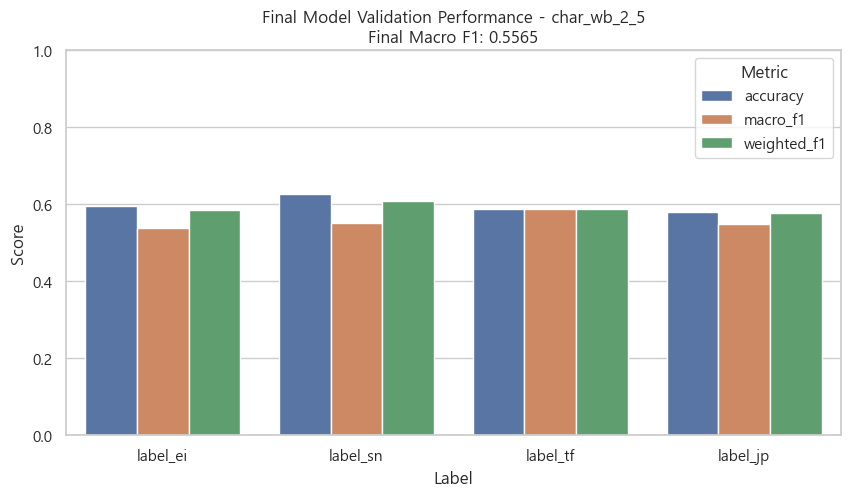

In [67]:
# 라벨별 성능 시각화

plot_df = final_result_df.melt(
    id_vars='label',
    value_vars=['accuracy', 'macro_f1', 'weighted_f1'],
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='label', y='score', hue='metric')

plt.title(f'Final Model Validation Performance - char_wb_2_5\nFinal Macro F1: {final_score:.4f}')
plt.ylim(0, 1)
plt.xlabel('Label')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.show()

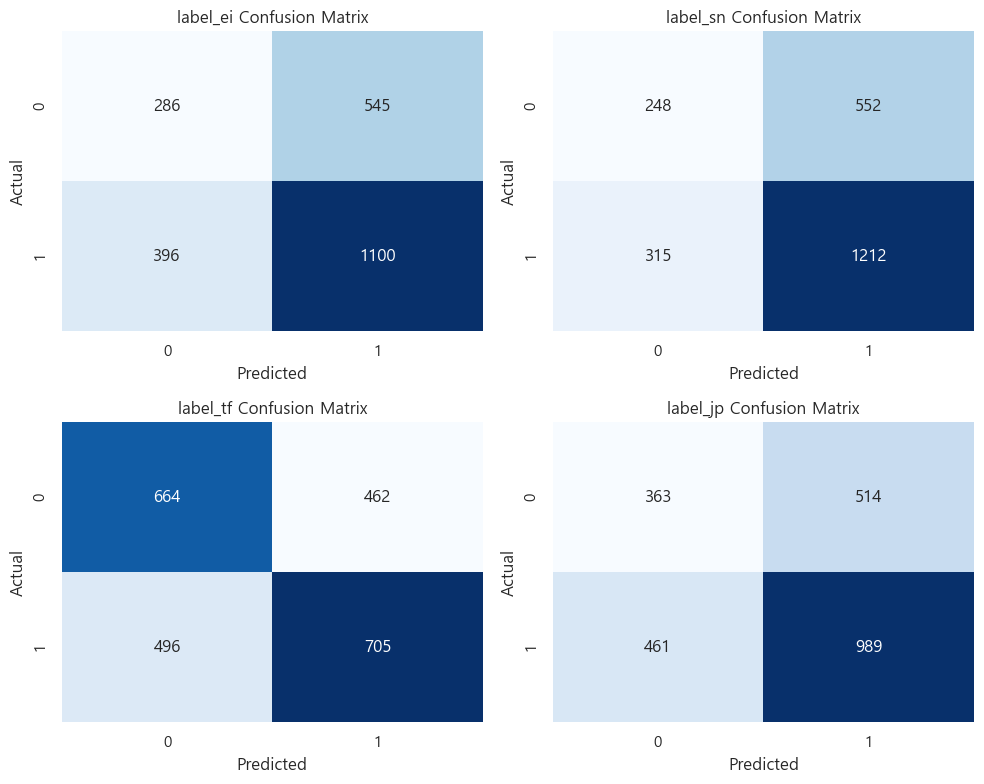

In [68]:
# Confusion Matrix 시각화
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, final_result_df.iterrows()):
    cm = row['confusion_matrix']

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{row['label']} Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

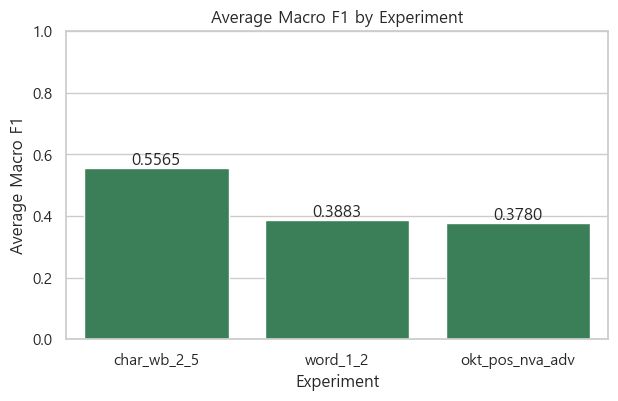

,experiment,macro_f1
0,char_wb_2_5,0.556491
2,word_1_2,0.388275
1,okt_pos_nva_adv,0.377962


In [69]:
# 기존 실험 비교 시각화

all_compare_df = pd.concat(
    [
        result_df.assign(experiment='word_1_2'),
        result_char_wb_df,
        result_okt_df
    ],
    ignore_index=True
)

summary_df = (
    all_compare_df
    .groupby('experiment', as_index=False)['macro_f1']
    .mean()
    .sort_values('macro_f1', ascending=False)
)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=summary_df, x='experiment', y='macro_f1', color='seagreen')

plt.title('Average Macro F1 by Experiment')
plt.ylim(0, 1)
plt.xlabel('Experiment')
plt.ylabel('Average Macro F1')

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.01,
        f"{p.get_height():.4f}",
        ha='center'
    )

plt.show()

display(summary_df)

In [70]:
# test data 적용 후 결과 확인

final_model_results = []

for target in TARGET_COLS:

    tfidf = TfidfVectorizer(
        max_features=20000,
        ngram_range=(2,5),
        min_df=2,
        max_df=0.9,
        analyzer='char_wb'
    )

    X_train = tfidf.fit_transform(train_df['text_base'])
    X_test = tfidf.transform(test_df['text_base'])
    y_train = train_df[target]
    y_test = test_df[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Confusion Matrix:")
    print(cm)

    final_model_results.append({
        'experiment':'final_model',
        'label': target,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'confusion_matrix':cm
    })

final_df = pd.DataFrame(final_model_results)
final_model_score = final_df['macro_f1'].mean()

Accuracy: 0.604
Macro F1: 0.553
Weighted F1: 0.5945
Confusion Matrix:
[[ 310  534]
 [ 388 1096]]
Accuracy: 0.6409
Macro F1: 0.5543
Weighted F1: 0.6244
Confusion Matrix:
[[ 233  516]
 [ 320 1259]]
Accuracy: 0.5872
Macro F1: 0.5868
Weighted F1: 0.5872
Confusion Matrix:
[[647 478]
 [483 720]]
Accuracy: 0.5687
Macro F1: 0.5406
Weighted F1: 0.5648
Confusion Matrix:
[[374 542]
 [462 950]]


In [72]:
# 실험 결과 시각화

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

final_result_df = final_df.copy()

display_cols = ['label', 'accuracy', 'macro_f1', 'weighted_f1']
display(final_result_df[display_cols])

final_score = final_result_df['macro_f1'].mean()
print('Final Macro F1 Score:', round(final_score, 4))

,label,accuracy,macro_f1,weighted_f1
0,label_ei,0.603952,0.552997,0.594487
1,label_sn,0.640893,0.554328,0.624357
2,label_tf,0.587199,0.586793,0.587227
3,label_jp,0.568729,0.540605,0.564823


Final Macro F1 Score: 0.5587


# 1. 사용한 전처리 방식

최종 모델에는 최소 전처리만 적용

- 모든 문자를 소문자로 변환
- URL 패턴 제거 시도
- 공백 문자 제거
- MBTI 직접 언급 제거는 실험했지만 최종 모델에는 적용하지 않음

# 2. 사용한 TF-IDF 설정

- TfidfVectorizer(
-    analyzer="char_wb",
-    ngram_range=(2, 5),
-    max_features=20000,
-    min_df=2,
-    max_df=0.9
- )
-
- 모델은 고정 조건대로 사용
-
- LinearSVC(
-    C=1.0,
-    max_iter=5000,
-    random_state=42
- )

# 3. 전처리 전/후 예시 3개

예시 1
- 전: 어렵게 생각하지 마세요~~  아마 infp님이 어렵게 생각을 해서 어려운 거예요~
- 후: 어렵게생각하지마세요~~아마infp님이어렵게생각을해서어려운거예요~

예시 2
- 전: 제 남자친구 estj인데 저희는 만약 합정에서 데이트하고 싶다 하면
- 후: 제남자친구estj인데저희는만약합정에서데이트하고싶다하면

예시 3
- 전: 생각이 많을 때 자주 그래요 먼가 결론이 나오는 경우도 있고요
- 후: 생각이많을때자주그래요먼가결론이나오는경우도있고요

# 4. 가장 성능이 높았던 라벨

최종 test 기준 Macro F1이 가장 높은 라벨은 label_tf

label_tf: Macro F1 = 0.5868

# 5. 가장 성능이 낮았던 라벨

최종 test 기준 Macro F1이 가장 낮은 라벨은 label_jp

label_jp: Macro F1 = 0.5406

최종 test 결과 요약:

- label_ei  Macro F1 = 0.5530
- label_sn  Macro F1 = 0.5543
- label_tf  Macro F1 = 0.5868
- label_jp  Macro F1 = 0.5406
- 
- Final Macro F1 = 0.5587

# 6. 결과 해석

- 단어 기반 TF-IDF와 형태소 기반 전처리는 accuracy는 비교적 높았지만 Macro F1이 낮았다. 
- 이는 다수 클래스를 중심으로 예측하면서 소수 클래스 예측이 약했기 때문으로 해석된다.
- 
- 반면 char_wb 기반 문자 n-gram은 
- 한국어 댓글의 띄어쓰기, 조사, 어미, 비표준 표현을 부분 문자열 단위로 포착할 수 있어 
- 4개 라벨 모두에서 더 균형 잡힌 Macro F1을 보였다.
- 
- 특히 label_tf는 네 라벨 중 가장 높은 Macro F1을 기록했는데, 
- T/F 축은 감정 표현, 공감 표현, 판단 방식과 관련된 언어적 단서가 
- 텍스트에 비교적 직접적으로 드러났을 가능성이 있다. 
- 반대로 label_jp는 가장 낮은 성능을 보였으며, 
- J/P 축은 문장 표면에서 드러나는 단서가 상대적으로 약하거나 상황 의존적인 표현이 많아 
- 구분이 어려웠던 것으로 해석된다.